# OREX Scan: Accettanza e Lavoro vs Protocol Steps

Questo notebook legge i run OREX e plotta:
- accettanza media di swap vs `orex_protocol_steps`
- lavoro medio (`work_mean`) vs `orex_protocol_steps`

con barre d'errore aggregate su tutta la statistica disponibile (batch inclusa).

In [7]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [8]:
RESULTS_DIR = Path('/Users/eliacellini/Desktop/scripting/neoqcd/results/pt_obc')
TARGET_STEPS = {1, 2, 4, 6}  # metti None per prendere tutti i valori disponibili


def mean_sem_from_moments(sum_x: float, sum_x2: float, count: int):
    n = int(count)
    if n <= 0:
        return float('nan'), float('nan')
    mean = float(sum_x) / float(n)
    if n == 1:
        return mean, float('nan')
    var_unbiased = (float(sum_x2) - (float(sum_x) * float(sum_x) / float(n))) / float(n - 1)
    var_unbiased = max(var_unbiased, 0.0)
    sem = math.sqrt(var_unbiased / float(n))
    return mean, sem


def row_to_moments(mean_val: float, sem_val: float, count: int):
    n = int(count)
    if n <= 0 or not np.isfinite(mean_val):
        return 0.0, 0.0, 0

    s = float(mean_val) * n

    if n == 1 or not np.isfinite(sem_val):
        ssq = float(mean_val) * float(mean_val)
        return s, ssq, n

    # sem = sqrt(var_unbiased / n) -> var_unbiased = sem^2 * n
    var_unbiased = float(sem_val) * float(sem_val) * n
    ssq = var_unbiased * (n - 1) + (s * s) / n
    return s, ssq, n


In [9]:
rows = []

for meta_path in sorted(RESULTS_DIR.glob('*/run_meta.json')):
    run_dir = meta_path.parent
    csv_path = run_dir / 'pt_metrics.csv'
    if not csv_path.exists():
        continue

    meta = json.loads(meta_path.read_text())
    args = meta.get('args', {})

    if args.get('algorithm') != 'orex':
        continue

    try:
        nsteps = int(args.get('orex_protocol_steps'))
    except (TypeError, ValueError):
        continue

    if TARGET_STEPS is not None and nsteps not in TARGET_STEPS:
        continue

    df = pd.read_csv(csv_path)
    if df.empty:
        continue

    total_prop = int(df['swap_n_proposed'].sum())
    total_acc = int(df['swap_n_accepted'].sum())

    if total_prop > 0:
        acc_mean = total_acc / total_prop
        acc_sem = math.sqrt(acc_mean * (1.0 - acc_mean) / total_prop)
    else:
        acc_mean = float('nan')
        acc_sem = float('nan')

    sum_w = 0.0
    sumsq_w = 0.0
    count_w = 0
    for _, r in df.iterrows():
        s, ssq, n = row_to_moments(r.get('work_mean', np.nan), r.get('work_sem', np.nan), r.get('work_count', 0))
        sum_w += s
        sumsq_w += ssq
        count_w += n

    work_mean, work_sem = mean_sem_from_moments(sum_w, sumsq_w, count_w)

    rows.append({
        'run_name': run_dir.name,
        'orex_protocol_steps': nsteps,
        'swap_acceptance_mean': acc_mean,
        'swap_acceptance_sem': acc_sem,
        'swap_total_proposed': total_prop,
        'swap_total_accepted': total_acc,
        'work_mean': work_mean,
        'work_sem': work_sem,
        'work_count': count_w,
    })

summary = pd.DataFrame(rows).sort_values('orex_protocol_steps').reset_index(drop=True)
summary

,run_name,orex_protocol_steps,swap_acceptance_mean,swap_acceptance_sem,swap_total_proposed,swap_total_accepted,work_mean,work_sem,work_count
0,orex_obc_cpu_r8_L2_s1,1,0.453333,0.007681,4200,1904,2.321706,0.048323,4200
1,orex_obc_cpu_r8_L2_s2,2,0.531667,0.007700,4200,2233,1.399874,0.034200,4200
2,orex_obc_cpu_r8_L2_s4,4,0.622619,0.007480,4200,2615,0.840336,0.024711,4200
3,orex_obc_cpu_r4_L2,6,0.664062,0.009110,2688,1785,NaN,NaN,0
4,orex_obc_cpu_r8_L2_s6,6,0.659762,0.007311,4200,2771,0.619904,0.020616,4200


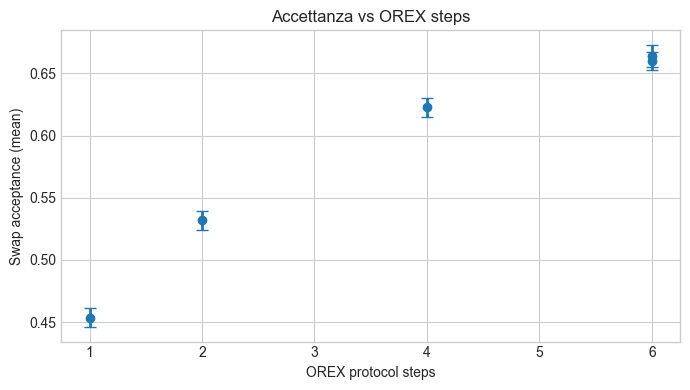

In [10]:
if summary.empty:
    raise RuntimeError('Nessun run OREX trovato con i filtri correnti.')

x = summary['orex_protocol_steps'].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    x,
    summary['swap_acceptance_mean'].to_numpy(),
    yerr=summary['swap_acceptance_sem'].to_numpy(),
    fmt='o',
    capsize=4,
    lw=2,
)
ax.set_xlabel('OREX protocol steps')
ax.set_ylabel('Swap acceptance (mean)')
ax.set_title('Accettanza vs OREX steps')
plt.tight_layout()
plt.show()


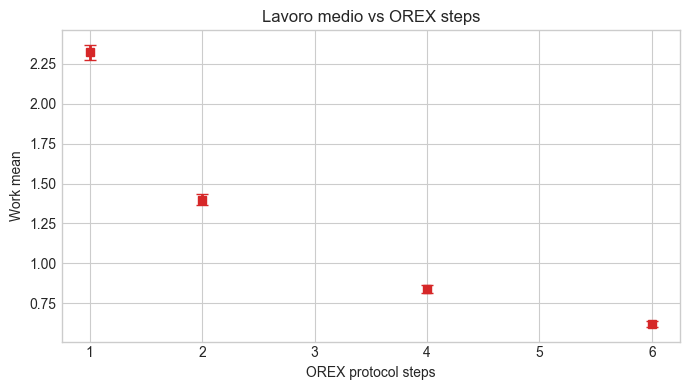

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    x,
    summary['work_mean'].to_numpy(),
    yerr=summary['work_sem'].to_numpy(),
    fmt='s',
    capsize=4,
    lw=2,
    color='tab:red',
)
ax.set_xlabel('OREX protocol steps')
ax.set_ylabel('Work mean')
ax.set_title('Lavoro medio vs OREX steps')
plt.tight_layout()
plt.show()


In [12]:
summary[['orex_protocol_steps', 'swap_acceptance_mean', 'swap_acceptance_sem', 'work_mean', 'work_sem', 'swap_total_proposed', 'work_count', 'run_name']]

,orex_protocol_steps,swap_acceptance_mean,swap_acceptance_sem,work_mean,work_sem,swap_total_proposed,work_count,run_name
0,1,0.453333,0.007681,2.321706,0.048323,4200,4200,orex_obc_cpu_r8_L2_s1
1,2,0.531667,0.007700,1.399874,0.034200,4200,4200,orex_obc_cpu_r8_L2_s2
2,4,0.622619,0.007480,0.840336,0.024711,4200,4200,orex_obc_cpu_r8_L2_s4
3,6,0.664062,0.009110,NaN,NaN,2688,0,orex_obc_cpu_r4_L2
4,6,0.659762,0.007311,0.619904,0.020616,4200,4200,orex_obc_cpu_r8_L2_s6
